<div class="row">
  <div class="column">
    <img src='./img/EUMETSAT-Logo.png' alt='Logo EUMETSAT' align='right' width='30%' />
  </div>
  <div class="column">
    <img src='./img/EUMETView_icon_white.png' alt='Logo EUMETView' align='left' width='52%' />
  </div>
</div>

Copyright (c) 2020 EUMETSAT <br>
License: MIT

<hr>

<a href="./index.ipynb"><< Index</a>
<br>
<a href="./4_Using_the_EUMETView_WFS_API.ipynb"><< Using the EUMETView WFS API</a>
<span style="float:right;">
<a href="./index.ipynb">Back to index >></a>

# Using the EUMETView WCS API

### <font color='red'>Modified copy for CSSE satellite group</font>

The WFS API can be used to programatically retrieve any **coverage** of a specific product from the EUMETView service. By coverage, we mean the actual values of the pixels that make up a map, and not just the map image. A good example of a coverage products are the chlorophyll product from the Copernicus Sentinel-3A OLCI sensor and sea surface temperature product from the Copnericus Sentinel-3 SLSTR sensor. These are on the same platform, so have roughly the same coverage. More information on WMS systems can be found at https://docs.geoserver.org/latest/en/user/services/wcs/index.html.

## What will this module teach you?

This module will show you how to:<br>
1. Obtain product coverage information from the EUMETView WCS API.
2. Learn how to get more details about the data.
3. Plot the data and create time-series for furtger analysis.

<hr>

As usual, we begin by importing the necessary libraries.

<i><b>Note:</b> we highly recommend that you have owslib version 0.20.0 or later, if you may receive SSL certificate warnings</i>

**<font color='red'>The project environment will need all these packages installed. Most should be on Conda, but eumdac is on pip</font>**

In [13]:
import os
import sys
import warnings
from IPython.core.display import HTML
from IPython.display import Image
from owslib.wcs import WebCoverageService
from owslib.util import Authentication
from owslib.fes import *
from time import sleep
import requests
import xml
from xml.etree import ElementTree
import netCDF4 as nc
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import eumdac
import ssl

import xarray as xr

# Turn off SSL certificate verification warnings
ssl._create_default_https_context = ssl._create_unverified_context
warnings.simplefilter("ignore")


Next we use our consumer key and secret to generate an access token. We use the EUMDAC Python library to generate a token, which we can later use in our requests. The <YOUR_CONSUMER_KEY> and <YOUR_CONSUMER_SECRET> are unique to each user and are essential for the authentication. To obtain them, log in to EumetView with your web browser, click on your username on the top right hand corner and then select 'API Key'. This will take you to the API key management page. You can then copy and paste these into the code cell bellow. 

**<font color='red'>I have just pasted in my personal key here, but we should update to an automatic read from file similar to play_w_sentinel3_eumetsat.ipynb</font>**

In [2]:
# Insert your personal key and secret into the single quotes
consumer_key = 'NuIve4rLXKqpMG6X7UoCI_8fVb8a'
consumer_secret = 'XGmZwA6bxOGH50iSbjlFibLprmUa'

# Provide the credentials (key, secret) for generating a token
credentials = (consumer_key, consumer_secret)

# Create a token object from the credentials
token = eumdac.AccessToken(credentials)

# Print the token and its expiration time
print(f"This token '{token}' expires {token.expiration}")

# Set up the authorization headers for future requests
auth_headers = {"Authorization": f"Bearer {token.access_token}"}

This token 'ba8ce649-c4b0-3892-ad80-2e6d1423f6d8' expires 2025-08-19 14:42:44.059749


We access the WCS service using the following API end-point URL

In [3]:
service_url = 'https://view.eumetsat.int/geoserver/wcs?'
wcs = WebCoverageService(service_url, auth=Authentication(verify=False), version='2.0.1', timeout=120)

Now we have a connection to the WMS, we need to identify the products or target_layers we want. In this instance we will choose two.
* copernicus__daily_sentinel3ab_olci_l2_chl_fullres
* copernicus__daily_sentinel3ab_slstr_l2p_sst_fullres

**<font color='red'>These are the daily layers, which would be good to have in the library, but we need the instantaneous data!!!</font>**

<font color='red'>We will start with these daily layers and then move to the satellite pass data</font>

In [4]:
target_layers = ['copernicus__daily_sentinel3ab_olci_l2_chl_fullres','copernicus__daily_sentinel3ab_slstr_l2p_sst_fullres'] # daily layers

<i>note: all WCS layers have a corresponding WMS layer, which in this case of <b>copernicus__sentinel3a_olci_l2_chl_fullres</b> would be <b>copernicus:sentinel3a_olci_l2_chl_fullres</b></i>. Also note that the WCS tag will change depending on the version of WCS used!

We also want to know what formats we can get the data in. This is service and method dependant. In this instance, we want to know what formats are available for a **getcoverage** request.

In [5]:
# check available output format options for layer 0: OLCI
for iter_format_option in wcs.contents[target_layers[0]].supportedFormats:
    print("Format option: ", iter_format_option)

# select format option
format_option = 'application/x-netcdf4'

Format option:  application/gml+xml
Format option:  application/x-gzip
Format option:  application/x-netcdf
Format option:  application/x-netcdf4
Format option:  image/jpeg
Format option:  image/png
Format option:  image/tiff
Format option:  image/tiff;application=geotiff
Format option:  text/plain


Coverage layers can be complex. To help us determine what options are available for each layer, we can launch a **DescribeCoverage** request for any layer. This gives us valuable information about the names of the axis the data is displayed on, for example. Lets describe the coverage for the Sentinel-3 OLCI chlorophyll product...

In [6]:
# describe the coverage
payload = {
    'service' : 'WCS',
    'access_token': token,
    'request' : 'DescribeCoverage',
    'version' : '2.0.1',
    'coverageID' : [target_layers[1]]
}

response = requests.get(service_url, params=payload, verify=False)
tree = ElementTree.fromstring(response.content)
ElementTree.dump(tree)

<ns0:CoverageDescriptions xmlns:gml32="http://www.opengis.net/gml/3.2" xmlns:ns0="http://www.opengis.net/wcs/2.0" xmlns:ns3="http://www.opengis.net/gmlcov/1.0" xmlns:ns5="http://www.geoserver.org/wcsgs/2.0" xmlns:ows200="http://www.opengis.net/ows/2.0" xmlns:swe20="http://www.opengis.net/swe/2.0" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:schemaLocation=" http://www.opengis.net/wcs/2.0 http://schemas.opengis.net/wcs/2.0/wcsDescribeCoverage.xsd http://www.geoserver.org/wcsgs/2.0 https://view.eumetsat.int/geoserver/schemas/wcs/2.0/wcsgs.xsd">
  <ns0:CoverageDescription gml32:id="copernicus__daily_sentinel3ab_slstr_l2p_sst_fullres">
    <gml32:description>Generated from ImageMosaic</gml32:description>
    <gml32:name>SLSTR Level 2 SST Daily Accumulated - Sentinel-3</gml32:name>
    <gml32:boundedBy>
      <gml32:EnvelopeWithTimePeriod srsName="http://www.opengis.net/def/crs/EPSG/0/4326" axisLabels="Lat Long time" uomLabels="Deg Deg s" srsDimension="2">
        <gml32:lowerC

Now we have access to all this information we can make a get coverage request. For help in using this function we can run *help(wcs.getCoverage)*. We begin by defining spatial and time bounds for our query. 

*Note: For more information on time stamps, please follow this link: https://docs.geoserver.org/stable/en/user/services/wms/time.html#wms-time*

*Note: WCS search boxes are (lon1,lat1,lon2,lat2)*

In [7]:
# Define region of interest
region = (111, -14, 114, -11) # order is lon1,lat1,lon2,lat2

# Set date and time 
time = ('2020-10-16T11:40:00.000Z','2020-10-16T12:50:00.000')

Now we construct our two get coverage requests (one for each layer)...

Starting with chlorophyll....

In [8]:
payload = {
    'identifier' : [target_layers[0],],
    'format' : 'application/x-netcdf4',
    'crs' : 'EPSG:4326',\
    'subsets' : [('Lat',region[1],region[3]),\
                 ('Long',region[0],region[2]), \
                 ('Time',time[0],time[1])],
    'access_token': token
}

output = wcs.getCoverage(**payload)

filename = './chl_snapshot.nc'
with open(filename, 'wb') as f:
    f.write(output.read())

In [9]:
output.geturl()

'https://view.eumetsat.int/geoserver/wcs?version=2.0.1&request=GetCoverage&service=WCS&CoverageID=copernicus__daily_sentinel3ab_olci_l2_chl_fullres&crs=EPSG:4326&format=application/x-netcdf4&access_token=ba8ce649-c4b0-3892-ad80-2e6d1423f6d8&subset=Lat(-14,-11)&subset=Long(111,114)&subset=Time(%222020-10-16T11:40:00.000Z%22,%222020-10-16T12:50:00.000%22)'

'https://view.eumetsat.int/geoserver/wcs/?request=GetCoverage&service=WCS&version=2.0.1&CoverageID=copernicus__sentinel3a_olci_l2_chl_fullres&subset=Lat%2835.0%2C37.0%29&subset=Long%28-5.5%2C-2.0%29&access_token=8cfe201c-a229-3b35-9f55-1a05bec1a658&format=application%2Fx-netcdf&crs=EPSG%3A4326&subset=%22Time%28%EF%BF%BD2020-06-19T09%3A00%3A00.000Z%22%22%2C%22%222020-06-19T09%3A59%3A59.999Z%22%22%29%22'

...and now sea surface temperature.

In [10]:
payload = {
    'identifier' : [target_layers[1]],
    'format' : 'application/x-netcdf4',
    'crs' : 'EPSG:4326',\
    'subsets' : [('Lat',region[1],region[3]),\
                 ('Long',region[0],region[2]), \
                 ('time',time[0],time[1])],
    'access_token': token
}

output = wcs.getCoverage(**payload)

filename = './sst_snapshot.nc'
with open(filename, 'wb') as f:
    f.write(output.read())

This data has been downloaded and written to netCDF files. This is a convenient format for working with gridded data. We can now open these files and read in the data. In this instance, we have only retrieved data for a single time step (so there is only 1 frame to plot).

**<font color='red'>Saving netCDF files using the netCDF4 package (as above) is a bit clunky. Worth updating to just save using xarray (.to_netcdf)</font>**


In [11]:
# open the netCDF files
nc_fid = nc.Dataset('chl_snapshot.nc')
lon1 = nc_fid.variables['lon'][:]
lat1 = nc_fid.variables['lat'][:]
var1 = nc_fid.variables[target_layers[0].replace('__','_')][:] # small string adaptation to match variable names to layer names
nc_fid.close()

nc_fid = nc.Dataset('sst_snapshot.nc')
lon2 = nc_fid.variables['lon'][:]
lat2 = nc_fid.variables['lat'][:]
# var2 = nc_fid.variables['Mosaic(' + target_layers[1].replace('__','_') + ')'][:] # small string adaptation to match variable names to layer names
var2 = nc_fid.variables[target_layers[1].replace('__','_')][:] # small string adaptation to match variable names to layer names
nc_fid.close()

In [14]:
ds = xr.open_dataset('chl_snapshot.nc')
print(np.nanmin(ds['copernicus_daily_sentinel3ab_olci_l2_chl_fullres']))
ds

0.01


<xarray.Dataset>
Dimensions:                                           (time: 1, lat: 300,
                                                       lon: 300)
Coordinates:
  * time                                              (time) datetime64[ns] 2...
  * lat                                               (lat) float32 -13.99 .....
  * lon                                               (lon) float32 111.0 ......
Data variables:
    copernicus_daily_sentinel3ab_olci_l2_chl_fullres  (time, lat, lon) float32 ...
Attributes:
    spatial_ref:   GEOGCS["WGS 84", \n DATUM["World Geodetic System 1984", \n...
    GeoTransform:  111.00293518066405 0.01 0.0 -11.004952697753907 0.0 -0.010...

**<font color='red'>Also write loading code in xarray (xr.open_dataset).</font>**


And now we can plot this data....

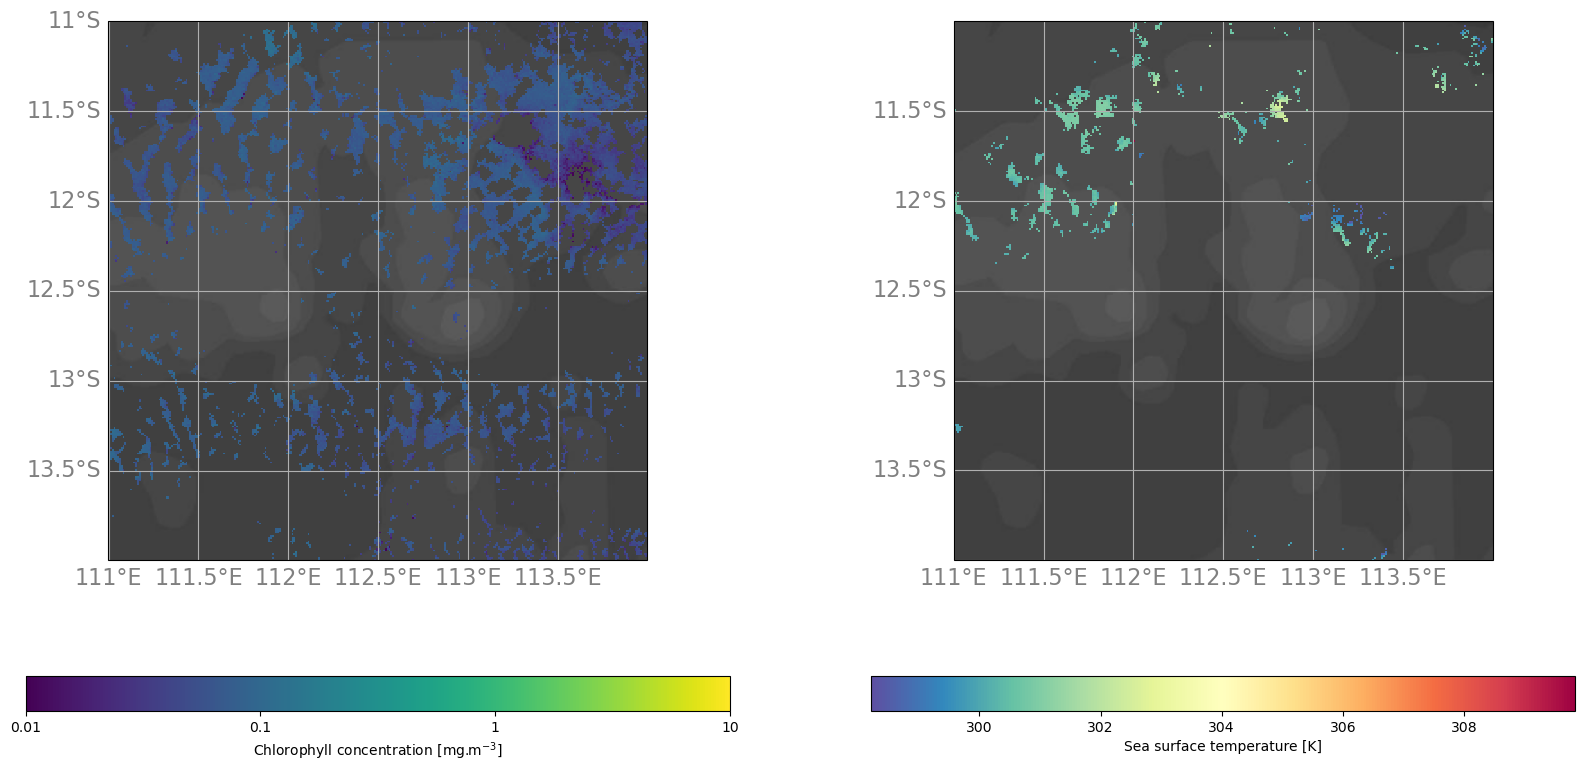

In [15]:
# plot the CHL netCDF variables:
fig = plt.figure(figsize=(20,10))
ax = plt.subplot(1,2,1, projection=ccrs.PlateCarree(central_longitude=0.0))
cmin = -2
cmax = 1
ticks=[10**x for x in range(cmin,cmax+1)]
p1 = plt.pcolormesh(lon1,lat1,np.log10(np.squeeze(var1[0])),cmap='viridis', vmin=cmin, vmax=cmax)
# add osm map and coastlines from EUMETView as background 
ax.add_wms(wms=service_url, layers=["osmgray:dark", "backgrounds:ne_10m_coastline"])
g1 = ax.gridlines(draw_labels = True)
g1.xlabels_top = False
g1.ylabels_right = False
g1.xlabel_style = {'size': 16, 'color': 'gray'}
g1.ylabel_style = {'size': 16, 'color': 'gray'}

# colourbar
cbar = plt.colorbar(p1, orientation='horizontal')
cbar.set_ticks(np.log10(ticks))
cbar.ax.set_xticklabels(ticks)
cbar.set_label('Chlorophyll concentration [mg.m$^{-3}$]')

# plot the SST netCDF variables:
ax = plt.subplot(1,2,2, projection=ccrs.PlateCarree(central_longitude=0.0))
p1 = plt.pcolormesh(lon2,lat2,np.squeeze(var2[0]),cmap='Spectral_r', vmin=np.nanmin(var2), vmax=np.nanmax(var2))
# add osm map and coastlines from EUMETView as background 
ax.add_wms(wms=service_url, layers=["osmgray:dark", "backgrounds:ne_10m_coastline"])
g1 = ax.gridlines(draw_labels = True)
g1.xlabels_top = False
g1.ylabels_right = False
g1.xlabel_style = {'size': 16, 'color': 'gray'}
g1.ylabel_style = {'size': 16, 'color': 'gray'}

# colourbar
cbar = plt.colorbar(p1, orientation='horizontal')
cbar.set_label('Sea surface temperature [K]')

plt.show()

Not much to see today but the function works

We are going to re-launch our WCS queries for the SST product for a longer period of time. The box below sets the bounds of our enquiry.

**<font color='red'>This is important because the query returns different things when we look for longer time periods - important to test.</font>**


In [16]:
# box area change over time
region = (111, -14, 114, -11) # order is lon1,lat1,lon2,lat2

time = ('2020-06-10T09:00:00.000Z','2020-06-12T09:59:59.999Z')

And, exactly as before, we will query the sea surface temperature data that matches this query.

In [17]:
payload = {
    'identifier' : [target_layers[1],],
    'format' : 'application/x-netcdf4',
    'crs' : 'EPSG:4326',\
    'subsets' : [('Lat',region[1],region[3]),\
                 ('Long',region[0],region[2]), \
                 ('time',time[0],time[1])],
    'access_token': token,
}

output = wcs.getCoverage(**payload)

filename = './sst_timeseries.nc'
with open(filename, 'wb') as f:
    f.write(output.read())

As before, we will load in the netCDF file where the data has been written. We will also do a bit of tinkering with the time variable to convert it from a *seconds since...* paradigm to an actual date. We will also average each of our variable over the ROI for each time step.

In [21]:
# quick funtion to convert seconds since to dates...You can get the timebase and reference time from the netCDF file metadata
date_convert = np.vectorize(lambda x: datetime.datetime(1970,1,1,0,0,0)+datetime.timedelta(seconds=x))


nc_fid = nc.Dataset('sst_timeseries.nc')
time2 = date_convert(nc_fid.variables['time'][:])
var2 = nc_fid.variables[target_layers[1].replace('__','_')][:]
# geometric average (grid size NOT taken into account)
var2 = np.nanmean(np.nanmean(var2,1),1)
nc_fid.close()

And finally, we can plot this time series data to see how the signals compare.

**<font color='red'>Again this nc package code is clunky. Xarray example below.</font>**


In [22]:
ds = xr.open_dataset('sst_timeseries.nc')
print(np.nanmin(ds['copernicus_daily_sentinel3ab_slstr_l2p_sst_fullres']))
ds

297.36


<xarray.Dataset>
Dimensions:                                             (time: 62, lat: 300,
                                                         lon: 300)
Coordinates:
  * time                                                (time) datetime64[ns] ...
  * lat                                                 (lat) float32 -14.0 ....
  * lon                                                 (lon) float32 111.0 ....
Data variables:
    copernicus_daily_sentinel3ab_slstr_l2p_sst_fullres  (time, lat, lon) float32 ...
Attributes:
    spatial_ref:   GEOGCS["WGS 84", \n DATUM["World Geodetic System 1984", \n...
    GeoTransform:  111.00495117187518 0.01 0.0 -11.005353698730527 0.0 -0.010...

**<font color='red'>Interesting that we get 'daily' data every few hours. Must ba a 24-hour average updated regularly. If the user tries to download a month of daily data the file will be very large, we will want to warn the user</font>**


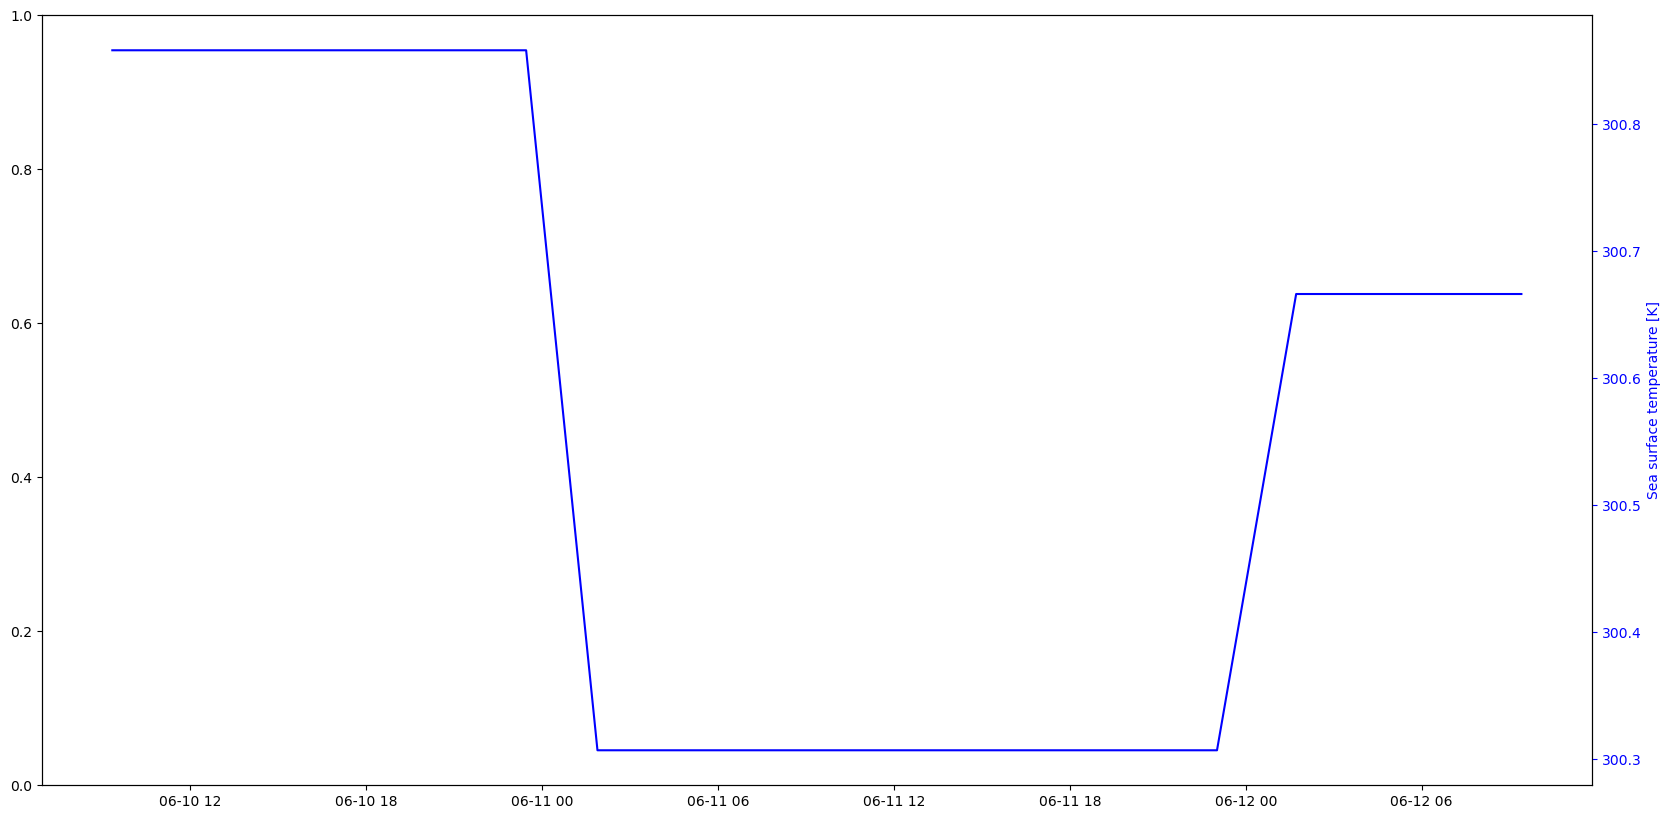

In [23]:
# plot the netCDF variables:
fig,ax1 = plt.subplots(figsize=(20,10))
ax2=ax1.twinx()
ax2.plot(time2[np.isfinite(var2)], var2[np.isfinite(var2)], color='b')
plt.ylabel('Sea surface temperature [K]', color='b')
ax2.tick_params(axis='y', colors='b')

plt.show()

**<font color='red'>The main thing we didn't do above is query the WCS service to see what downloads are available before downloading. I will search other notebooks for this, but you could look into this too.</font>**

# End of original notebook

#### Now we will look at getting the most recent data that is not interpolated

In [24]:
target_layers = ['copernicus__sentinel3a_slstr_l2p_sst_fullres', 'copernicus__sentinel3b_slstr_l2p_sst_fullres',\
                 'copernicus__sentinel3a_olci_l2_chl_fullres', 'copernicus__sentinel3b_olci_l2_chl_fullres']

time = ('2021-05-16T10:40:00.000Z','2021-05-18T23:50:00.000')

In [25]:
# check available output format options for layer 0: OLCI
for iter_format_option in wcs.contents[target_layers[0]].supportedFormats:
    print("Format option: ", iter_format_option)

Format option:  application/gml+xml
Format option:  application/x-gzip
Format option:  application/x-netcdf
Format option:  application/x-netcdf4
Format option:  image/jpeg
Format option:  image/png
Format option:  image/tiff
Format option:  image/tiff;application=geotiff
Format option:  text/plain


In [26]:
# select format option
format_option = 'application/x-netcdf'

crs_option = 'EPSG:4326'

Maybe there is a request like this below to find out what data is available?

In [27]:
# describe the coverage
payload = {
    'service' : 'WCS',
    'access_token': token,
    'request' : 'DescribeCoverage',
    'version' : '2.0.1',
    'coverageID' : [target_layers[0]]
}

response = requests.get(service_url, params=payload, verify=False)
tree = ElementTree.fromstring(response.content)
ElementTree.dump(tree)

<ns0:CoverageDescriptions xmlns:gml32="http://www.opengis.net/gml/3.2" xmlns:ns0="http://www.opengis.net/wcs/2.0" xmlns:ns3="http://www.opengis.net/gmlcov/1.0" xmlns:ns5="http://www.geoserver.org/wcsgs/2.0" xmlns:ows200="http://www.opengis.net/ows/2.0" xmlns:swe20="http://www.opengis.net/swe/2.0" xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance" xsi:schemaLocation=" http://www.opengis.net/wcs/2.0 http://schemas.opengis.net/wcs/2.0/wcsDescribeCoverage.xsd http://www.geoserver.org/wcsgs/2.0 https://view.eumetsat.int/geoserver/schemas/wcs/2.0/wcsgs.xsd">
  <ns0:CoverageDescription gml32:id="copernicus__sentinel3a_slstr_l2p_sst_fullres">
    <gml32:description>Generated from ImageMosaic</gml32:description>
    <gml32:name>SLSTR Level 2 Sea Surface Temperature (SST) - Sentinel-3A</gml32:name>
    <gml32:boundedBy>
      <gml32:EnvelopeWithTimePeriod srsName="http://www.opengis.net/def/crs/EPSG/0/4326" axisLabels="Lat Long time" uomLabels="Deg Deg s" srsDimension="2">
        <gml32:lowe

Using same box as above. Short time

In [28]:
payload = {
    'identifier' : [target_layers[0],],
    'format' : format_option,
    'crs' : crs_option,\
    'subsets' : [('Lat',region[1],region[3]),\
                 ('Long',region[0],region[2]), \
                 ('Time',time[0],time[1])],
    'access_token': token
}

output = wcs.getCoverage(**payload)
filename = './sentinela_sst.nc'
with open(filename, 'wb') as f:
    f.write(output.read())

In [29]:
sentinela_sst_ds = xr.open_dataset('sentinela_sst.nc')
print(np.nanmax(sentinela_sst_ds['copernicus_sentinel3a_slstr_l2p_sst_fullres']))
sentinela_sst_ds

301.82


<xarray.Dataset>
Dimensions:                                      (time: 18, lat: 300, lon: 300)
Coordinates:
  * time                                         (time) datetime64[ns] 2021-0...
  * lat                                          (lat) float32 -14.0 ... -11.01
  * lon                                          (lon) float32 111.0 ... 114.0
Data variables:
    copernicus_sentinel3a_slstr_l2p_sst_fullres  (time, lat, lon) float32 nan...
Attributes:
    spatial_ref:   GEOGCS["WGS 84", \n DATUM["World Geodetic System 1984", \n...
    GeoTransform:  111.00495117187518 0.01 0.0 -11.005361328125073 0.0 -0.010...

In [30]:
payload = {
    'identifier' : [target_layers[1],],
    'format' : format_option,
    'crs' : crs_option,\
    'subsets' : [('Lat',region[1],region[3]),\
                 ('Long',region[0],region[2]), \
                 ('Time',time[0],time[1])],
    'access_token': token
}

output = wcs.getCoverage(**payload)
filename = './sentinelb_sst.nc'
with open(filename, 'wb') as f:
    f.write(output.read())

In [31]:
sentinelb_sst_ds = xr.open_dataset(filename)
print(np.nanmax(sentinelb_sst_ds['copernicus_sentinel3b_slstr_l2p_sst_fullres']))
sentinelb_sst_ds

304.96


<xarray.Dataset>
Dimensions:                                      (time: 21, lat: 300, lon: 300)
Coordinates:
  * time                                         (time) datetime64[ns] 2021-0...
  * lat                                          (lat) float32 -14.0 ... -11.01
  * lon                                          (lon) float32 111.0 ... 114.0
Data variables:
    copernicus_sentinel3b_slstr_l2p_sst_fullres  (time, lat, lon) float32 nan...
Attributes:
    spatial_ref:   GEOGCS["WGS 84", \n DATUM["World Geodetic System 1984", \n...
    GeoTransform:  111.00495117187518 0.01 0.0 -11.005384216308666 0.0 -0.010...

I'm pretty sure sentinel b failed because there was no data inside our box during the request time. This will need to be handled automatically. 

In [32]:
payload = {
    'identifier' : [target_layers[2],],
    'format' : format_option,
    'crs' : crs_option,\
    'subsets' : [('Lat',region[1],region[3]),\
                 ('Long',region[0],region[2]), \
                 ('Time',time[0],time[1])],
    'access_token': token
}

output = wcs.getCoverage(**payload)
filename = './sentinela_chl.nc'
with open(filename, 'wb') as f:
    f.write(output.read())

In [33]:
sentinela_chl_ds = xr.open_dataset('sentinela_chl.nc')
print(np.nanmax(sentinela_chl_ds['copernicus_sentinel3a_olci_l2_chl_fullres']))
sentinela_chl_ds

0.4503429


<xarray.Dataset>
Dimensions:                                    (time: 33, lat: 300, lon: 300)
Coordinates:
  * time                                       (time) datetime64[ns] 2021-05-...
  * lat                                        (lat) float32 -13.99 ... -11.0
  * lon                                        (lon) float32 111.0 ... 114.0
Data variables:
    copernicus_sentinel3a_olci_l2_chl_fullres  (time, lat, lon) float32 nan ....
Attributes:
    spatial_ref:   GEOGCS["WGS 84", \n DATUM["World Geodetic System 1984", \n...
    GeoTransform:  111.00298095703124 0.01 0.0 -11.004952697753907 0.0 -0.010...

In [34]:
payload = {
    'identifier' : [target_layers[3],],
    'format' : format_option,
    'crs' : crs_option,\
    'subsets' : [('Lat',region[1],region[3]),\
                 ('Long',region[0],region[2]), \
                 ('Time',time[0],time[1])],
    'access_token': token
}

output = wcs.getCoverage(**payload)
filename = './sentinelb_chl.nc'
with open(filename, 'wb') as f:
    f.write(output.read())

In [35]:
sentinelb_chl_ds = xr.open_dataset('sentinelb_chl.nc')
sentinelb_chl_ds

<xarray.Dataset>
Dimensions:                                    (time: 31, lat: 300, lon: 300)
Coordinates:
  * time                                       (time) datetime64[ns] 2021-05-...
  * lat                                        (lat) float32 -13.99 ... -11.0
  * lon                                        (lon) float32 111.0 ... 114.0
Data variables:
    copernicus_sentinel3b_olci_l2_chl_fullres  (time, lat, lon) float32 ...
Attributes:
    spatial_ref:   GEOGCS["WGS 84", \n DATUM["World Geodetic System 1984", \n...
    GeoTransform:  111.00277160644532 0.01 0.0 -11.004952697753907 0.0 -0.010...

Interesting that SST failed for b but CHL succeeded. Maybe no good data for SST but some good data for CHL?

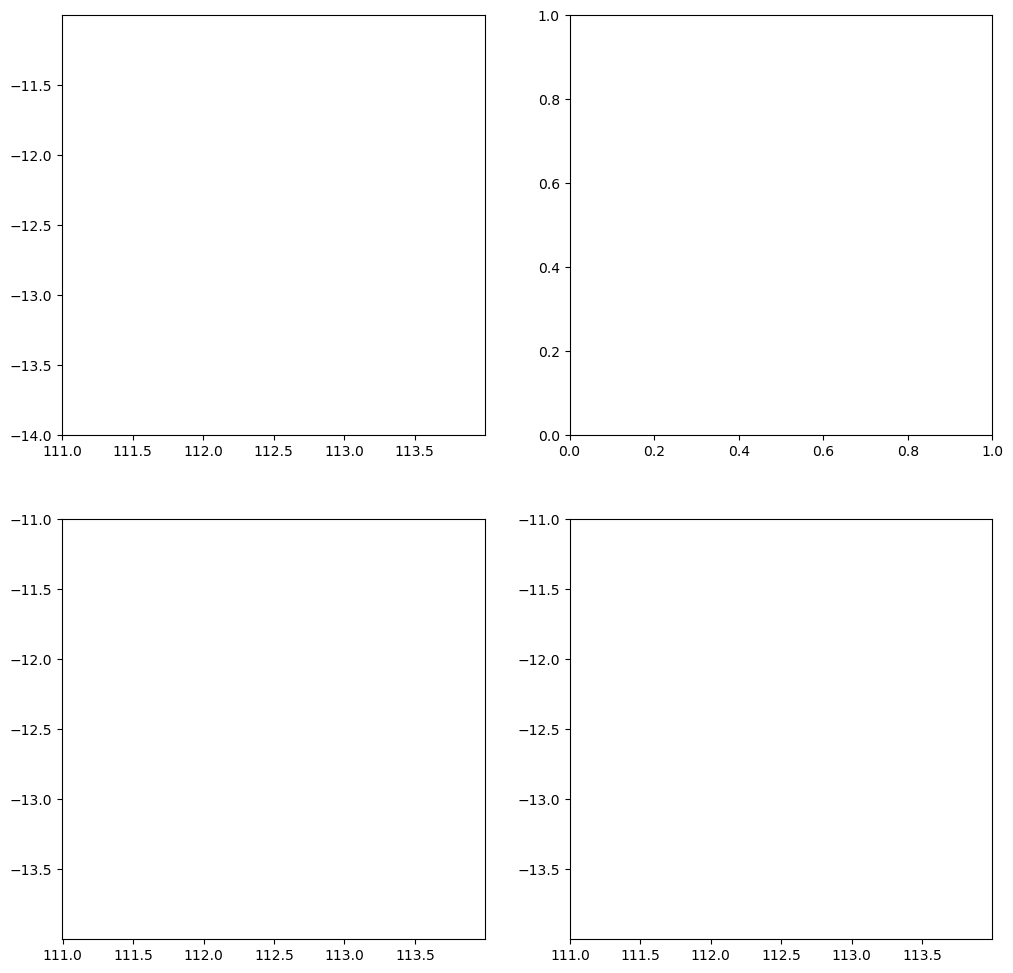

In [36]:
# plot the CHL netCDF variables:
fig, ax = plt.subplots(2,2, figsize=(12,12))

ds_list = [sentinela_sst_ds, None, sentinela_chl_ds, sentinelb_chl_ds]

for i, (x, ds) in enumerate(zip(ax.flatten(), ds_list)):
    if i != 1: #bad dataset return
        p1 = x.pcolormesh(ds['lon'], ds['lat'], ds.isel(time=0)[list(ds.keys())[0]], cmap='viridis')
        # x.set_title(ds.attrs['title'])
        # fig.colorbar(p1, ax=x, orientation='horizontal')

**We can see that most of the data is NaN**. This is fine, just need to be able to deal with it. And we probably can just delete layers that are all NaN from the archive so they don't show up as options in the plotting? But maybe we want to keep some kind of record of which layers were all NaN. Anyway, just use the basic code for now.

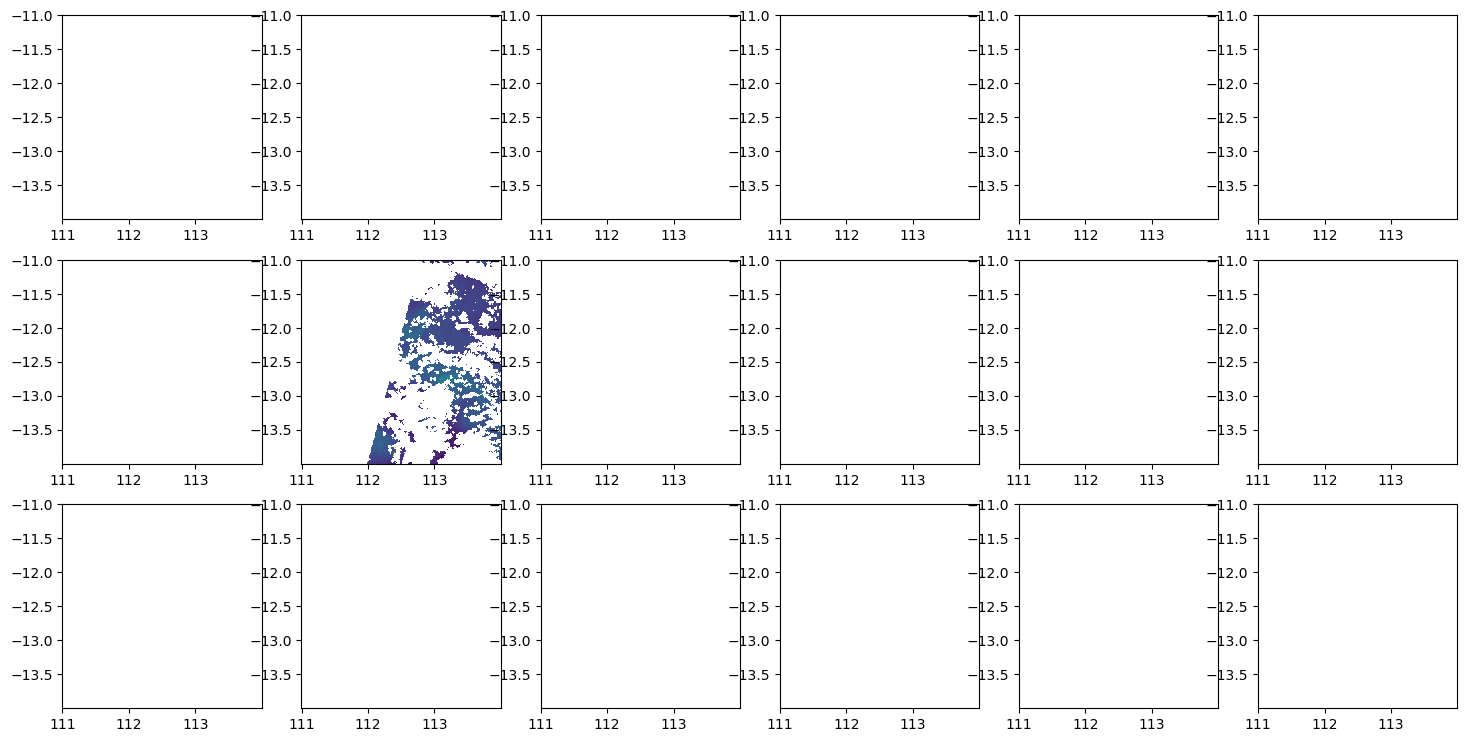

In [ ]:
fig, ax = plt.subplots(3,6, figsize=(18,9))

for i, x in enumerate(ax.flatten()):
    p1 = x.pcolormesh(sentinela_chl_ds['lon'],
                      sentinela_chl_ds['lat'],
                      sentinela_chl_ds.isel(time=i)[list(sentinela_chl_ds.keys())[0]],
                      cmap='viridis')

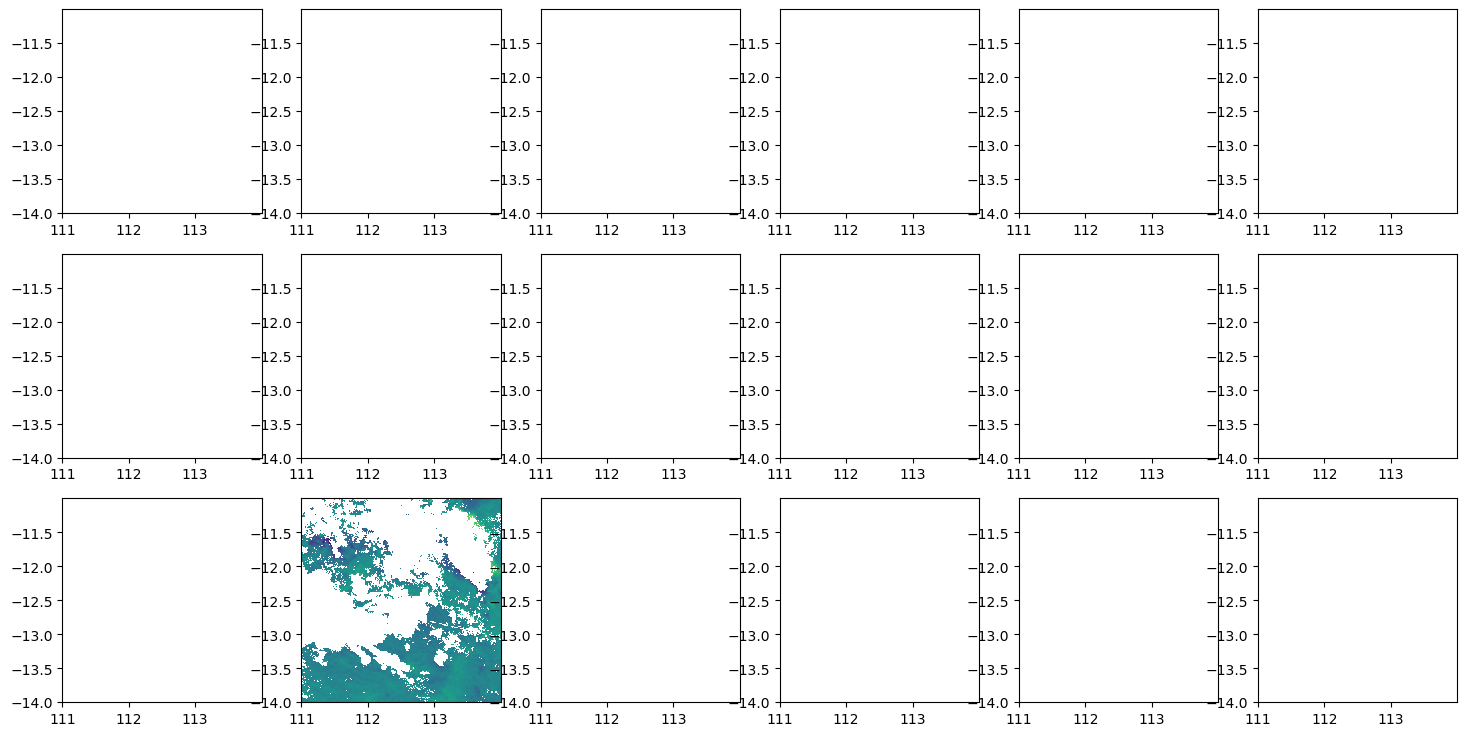

In [42]:
fig, ax = plt.subplots(3,6, figsize=(18,9))

for i, x in enumerate(ax.flatten()):
    p1 = x.pcolormesh(sentinelb_sst_ds['lon'],
                      sentinelb_sst_ds['lat'],
                      sentinelb_sst_ds.isel(time=i)[list(sentinelb_sst_ds.keys())[0]],
                      cmap='viridis')